In [ ]:
# 3D SVM Demonstration
# Concepts: Hyperplane (plane), Margin, Support Vectors, Decision Boundary
# Visualized in 3D space

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os

In [3]:
# 1. Load or create a 3D dataset from local file
# We create a synthetic 3D binary classification dataset (3 features for 3D plotting)
# and save it as a CSV file to simulate loading from a local drive.
file_name = 'svm_dataset_3d.csv'

if not os.path.exists(file_name):
    from sklearn.datasets import make_classification
    # n_features=3 gives us a 3D feature space
    X, y = make_classification(
        n_samples=300,
        n_features=3,
        n_redundant=0,
        n_clusters_per_class=1,
        flip_y=0.05,
        random_state=42
    )
    df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2', 'Feature_3'])
    df['Target'] = y
    df.to_csv(file_name, index=False)
    print(f"Created synthetic 3D dataset and saved as '{file_name}'")
else:
    df = pd.read_csv(file_name)
    print(f"Loaded 3D dataset from '{file_name}'")

# Extract features and target
X = df[['Feature_1', 'Feature_2', 'Feature_3']].values
y = df['Target'].values

print(f"Dataset shape: {X.shape}")
print(f"Class distribution: {np.bincount(y)}")

Loaded 3D dataset from 'svm_dataset_3d.csv'
Dataset shape: (300, 3)
Class distribution: [150 150]


In [4]:
# 2. Preprocessing: Standardization (important for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# 3. Train a Linear SVM (for 3D features)
# Linear kernel -> hyperplane is a plane in 3D
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [6]:
# 4. Evaluate the model
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\n=== Model Evaluation ===")
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Model Evaluation ===
Accuracy: 0.900

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        30
           1       0.93      0.87      0.90        30

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60

Confusion Matrix:
[[28  2]
 [ 4 26]]


In [7]:
# 5. Extract SVM components for 3D
# For linear SVM in 3D: w0*x0 + w1*x1 + w2*x2 + b = 0 is the hyperplane (plane)
w = svm_model.coef_[0]          # shape (3,)
b = svm_model.intercept_[0]

print("\n=== SVM Parameters (Linear Kernel, 3D) ===")
print(f"Weights (w): {w}")
print(f"Intercept (b): {b:.4f}")
print(f"Number of support vectors: {len(svm_model.support_vectors_)}")


=== SVM Parameters (Linear Kernel, 3D) ===
Weights (w): [0.33214075 0.17332464 1.71381297]
Intercept (b): 0.0182
Number of support vectors: 80


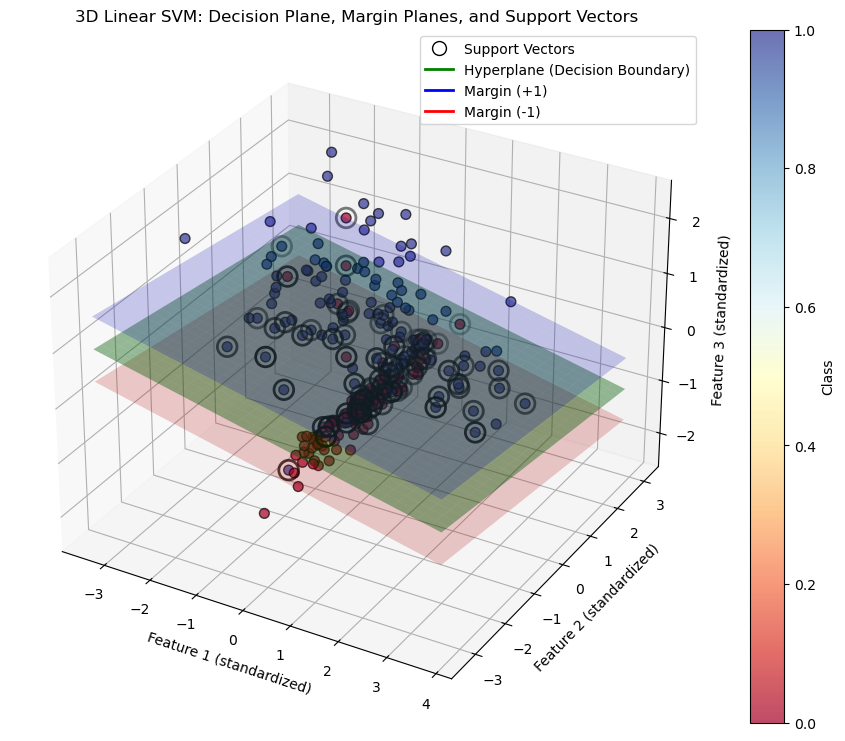

In [8]:
# 6. Visualization in 3D
# We'll plot:
#   - Data points colored by class
#   - The hyperplane (decision boundary)
#   - The two margin planes (w·x + b = ±1)
#   - Support vectors highlighted

def plot_3d_svm(model, X, y, scaler, title="SVM in 3D: Hyperplane, Margins, Support Vectors"):
    # Work with scaled features (X is already scaled here)
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot data points
    scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2],
                         c=y, cmap=plt.cm.RdYlBu, s=50,
                         edgecolors='k', alpha=0.7)
    
    # Plot support vectors (larger circles with black edge)
    support_vectors = model.support_vectors_
    ax.scatter(support_vectors[:, 0], support_vectors[:, 1], support_vectors[:, 2],
               s=200, facecolors='none', edgecolors='k', linewidth=2,
               label='Support Vectors')
    
    # Create a mesh grid for the plane (hyperplane)
    # We need to define a plane: w0*x + w1*y + w2*z + b = 0
    # Solve for z: z = (-b - w0*x - w1*y) / w2   (if w2 != 0)
    # Use a grid in (x,y) and compute corresponding z
    # For better visualization, we find the bounds of the data
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # Create a fine grid
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 30),
                         np.linspace(y_min, y_max, 30))
    
    # Avoid division by zero (if w2 is very small, we handle differently)
    # For robustness, we can also solve for x or y, but here we assume w2 not zero.
    # If w2 is nearly zero, we can rotate the plot or note it. For synthetic data it's fine.
    if abs(w[2]) > 1e-6:
        # Hyperplane: z = (-b - w[0]*xx - w[1]*yy) / w[2]
        z_hp = (-b - w[0]*xx - w[1]*yy) / w[2]
        # Margin planes: w·x + b = ±1  ->  z = (-b ± 1 - w[0]*xx - w[1]*yy) / w[2]
        z_margin_pos = (-b + 1 - w[0]*xx - w[1]*yy) / w[2]
        z_margin_neg = (-b - 1 - w[0]*xx - w[1]*yy) / w[2]
        
        # Plot the hyperplane (translucent)
        ax.plot_surface(xx, yy, z_hp, alpha=0.4, color='green', label='Hyperplane (Decision Boundary)')
        # Plot margin planes (semi-transparent)
        ax.plot_surface(xx, yy, z_margin_pos, alpha=0.2, color='blue', label='Margin (+1)')
        ax.plot_surface(xx, yy, z_margin_neg, alpha=0.2, color='red', label='Margin (-1)')
    else:
        print("Warning: w[2] is very small; plane visualization might be inaccurate.")
        # Alternative: solve for y or x; but for demonstration we skip detailed fallback.
    
    # Labels and title
    ax.set_xlabel('Feature 1 (standardized)')
    ax.set_ylabel('Feature 2 (standardized)')
    ax.set_zlabel('Feature 3 (standardized)')
    ax.set_title(title)
    
    # Custom legend for support vectors (manually add)
    # Since plot_surface doesn't support label directly well, we add a dummy patch
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', label='Support Vectors',
                              markerfacecolor='none', markeredgecolor='k', markersize=10),
                       Line2D([0], [0], color='green', lw=2, label='Hyperplane (Decision Boundary)'),
                       Line2D([0], [0], color='blue', lw=2, label='Margin (+1)'),
                       Line2D([0], [0], color='red', lw=2, label='Margin (-1)')]
    ax.legend(handles=legend_elements, loc='best')
    
    # Colorbar
    fig.colorbar(scatter, ax=ax, label='Class')
    plt.show()

# Plot using the training data (already scaled)
plot_3d_svm(svm_model, X_train, y_train, scaler,
            title="3D Linear SVM: Decision Plane, Margin Planes, and Support Vectors")



Generating interactive 3D plot with Plotly...


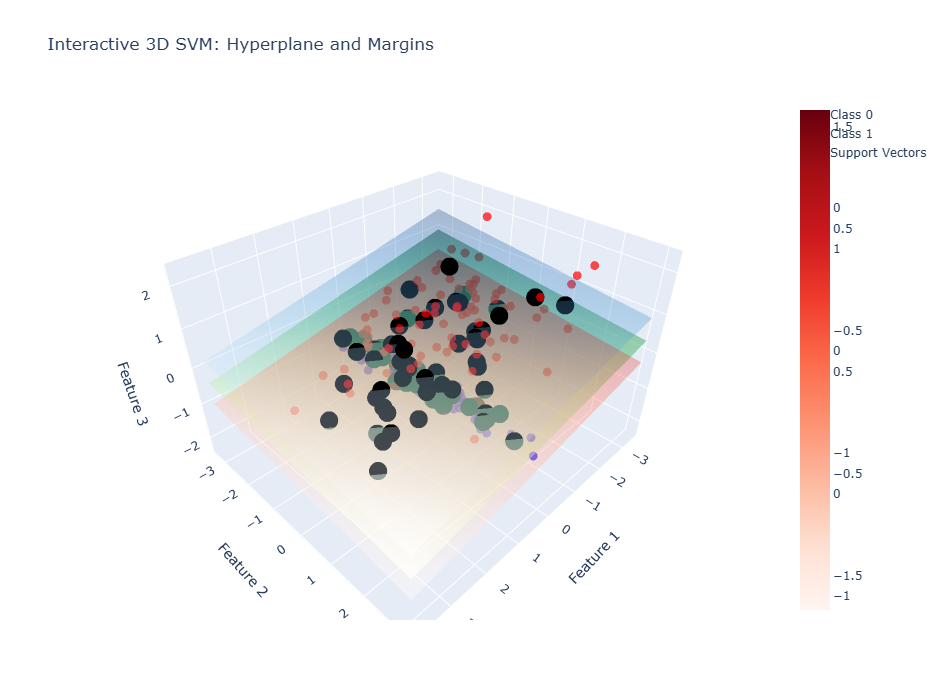

In [9]:
# 7. Additional: Interactive 3D plot using plotly (optional but nice)
# If plotly is installed, we can create an interactive plot.
# This helps students rotate and zoom to understand the geometry.
try:
    import plotly.graph_objects as go
    import plotly.express as px
    plotly_available = True
except ImportError:
    plotly_available = False
    print("\nPlotly not installed. Install with: pip install plotly for interactive 3D visualization.")

if plotly_available:
    print("\nGenerating interactive 3D plot with Plotly...")
    
    # Prepare data
    df_plot = pd.DataFrame(X_train, columns=['x', 'y', 'z'])
    df_plot['class'] = y_train.astype(str)
    
    # Create scatter plot of data points
    fig = go.Figure()
    
    # Add data points colored by class
    for class_val, color in zip([0, 1], ['blue', 'red']):
        mask = df_plot['class'] == str(class_val)
        fig.add_trace(go.Scatter3d(
            x=df_plot.loc[mask, 'x'],
            y=df_plot.loc[mask, 'y'],
            z=df_plot.loc[mask, 'z'],
            mode='markers',
            marker=dict(size=5, color=color, opacity=0.7),
            name=f'Class {class_val}'
        ))
    
    # Add support vectors
    sv = svm_model.support_vectors_
    fig.add_trace(go.Scatter3d(
        x=sv[:, 0], y=sv[:, 1], z=sv[:, 2],
        mode='markers',
        marker=dict(size=10, color='black', symbol='circle', line=dict(width=2, color='black')),
        name='Support Vectors'
    ))
    
    # Create mesh for the hyperplane and margins
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 20),
                         np.linspace(y_min, y_max, 20))
    
    if abs(w[2]) > 1e-6:
        z_hp = (-b - w[0]*xx - w[1]*yy) / w[2]
        z_pos = (-b + 1 - w[0]*xx - w[1]*yy) / w[2]
        z_neg = (-b - 1 - w[0]*xx - w[1]*yy) / w[2]
        
        # Hyperplane
        fig.add_trace(go.Surface(x=xx, y=yy, z=z_hp, opacity=0.5, colorscale='Greens', name='Hyperplane'))
        # Margin planes
        fig.add_trace(go.Surface(x=xx, y=yy, z=z_pos, opacity=0.3, colorscale='Blues', name='Margin +1'))
        fig.add_trace(go.Surface(x=xx, y=yy, z=z_neg, opacity=0.3, colorscale='Reds', name='Margin -1'))
    
    fig.update_layout(
        title='Interactive 3D SVM: Hyperplane and Margins',
        scene=dict(
            xaxis_title='Feature 1',
            yaxis_title='Feature 2',
            zaxis_title='Feature 3'
        ),
        width=900,
        height=700
    )
    fig.show()
else:
    print("Install plotly for interactive 3D visualization: pip install plotly")

In [10]:
# 8. Explanation of SVM in 3D for Students
print("\n=== Key SVM Concepts in 3D ===")
print("1. Hyperplane (Decision Boundary):")
print("   In 3D, the decision boundary is a PLANE: w0*x + w1*y + w2*z + b = 0")
print("   It separates the two classes.")
print()
print("2. Margin:")
print("   The distance between the hyperplane and the closest points from each class.")
print("   In 3D, the margin is defined by two parallel planes: w·x + b = ±1")
print("   The margin width = 2/||w|| (Euclidean norm of w).")
print()
print("3. Support Vectors:")
print("   Data points that lie exactly on the margin planes (or within, for soft margin).")
print("   They 'support' the hyperplane. In the plot, they are shown as hollow circles.")
print()
print("4. Decision Function:")
print("   f(x) = w·x + b. Its sign gives the predicted class; magnitude gives distance.")
print()
print("5. Soft Margin (C parameter):")
print("   C = 1.0 allows some misclassifications to achieve a wider margin.")
print("   This helps when data is not perfectly separable.")
print()
print("6. Why 3D?")
print("   Understanding 2D (line) and 3D (plane) helps generalize to higher dimensions")
print("   where the hyperplane becomes a 'hyperplane' (dimension = n_features - 1).")


=== Key SVM Concepts in 3D ===
1. Hyperplane (Decision Boundary):
   In 3D, the decision boundary is a PLANE: w0*x + w1*y + w2*z + b = 0
   It separates the two classes.

2. Margin:
   The distance between the hyperplane and the closest points from each class.
   In 3D, the margin is defined by two parallel planes: w·x + b = ±1
   The margin width = 2/||w|| (Euclidean norm of w).

3. Support Vectors:
   Data points that lie exactly on the margin planes (or within, for soft margin).
   They 'support' the hyperplane. In the plot, they are shown as hollow circles.

4. Decision Function:
   f(x) = w·x + b. Its sign gives the predicted class; magnitude gives distance.

5. Soft Margin (C parameter):
   C = 1.0 allows some misclassifications to achieve a wider margin.
   This helps when data is not perfectly separable.

6. Why 3D?
   Understanding 2D (line) and 3D (plane) helps generalize to higher dimensions
   where the hyperplane becomes a 'hyperplane' (dimension = n_features - 1).
